In [1]:
%pip install torch torchvision opencv-python-headless mediapipe matplotlib tqdm

INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 

In [2]:
%pip install torchvision opencv-python numpy torch

In [8]:
# ==================================================================
# 1. 기본 설정 및 라이브러리 임포트
# ==================================================================
import os
import zipfile
import json
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from google.colab import drive
import shutil
import cv2
import mediapipe as mp
import re
from sklearn.utils.class_weight import compute_class_weight

print("✅ 1. 라이브러리 임포트 완료")

✅ 1. 라이브러리 임포트 완료


In [3]:
# ==================================================================
# 2. 경로 설정 및 데이터 준비 (경로 자동 보정 추가)
# ==================================================================
drive.mount('/content/drive')

# --- ⭐️ 자신의 Google Drive 경로에 맞게 수정해주세요 ---
ZIP_FILE_PATH = '/content/drive/MyDrive/handshacke/dataset2.zip'
EXTRACT_PATH = '/content/handshacke_dataset2' # 압축을 풀 기본 경로
MODEL_SAVE_DIR = '/content/drive/MyDrive/handshacke/final_model_5_words_corrected'
os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# --- 원본 데이터 압축 해제 ---
if not os.path.exists(os.path.join(EXTRACT_PATH, 'Training', 'videos')) and not os.path.exists(os.path.join(EXTRACT_PATH, 'handshacke_dataset2')):
    print(f"'{ZIP_FILE_PATH}' 압축 해제 중...")
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("압축 해제 완료!")
else:
    print("데이터 폴더가 이미 존재합니다. 압축 해제를 건너뜁니다.")

# ▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
# [핵심 수정] 압축 해제 후 경로 자동 보정
# ========================================================
unzipped_contents = os.listdir(EXTRACT_PATH)
# 만약 압축 푼 폴더 안에 폴더가 하나만 있다면, 그 안으로 경로를 재설정
if len(unzipped_contents) == 1 and os.path.isdir(os.path.join(EXTRACT_PATH, unzipped_contents[0])):
    print(f"압축 해제 후 경로에 하위 폴더 '{unzipped_contents[0]}'가 감지되었습니다. 경로를 수정합니다.")
    EXTRACT_PATH = os.path.join(EXTRACT_PATH, unzipped_contents[0])
    print(f"-> 새로운 기본 경로: {EXTRACT_PATH}")
# ========================================================
# ▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲

print("\n✅ 2. 경로 설정 및 데이터 준비 완료")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/handshacke/dataset2.zip' 압축 해제 중...
압축 해제 완료!

✅ 2. 경로 설정 및 데이터 준비 완료


In [4]:
# ==================================================================
# 3. MediaPipe 기반 데이터셋 사전처리
# ==================================================================
print("\n✅ 3. MediaPipe 기반 사전처리 시작")
TARGET_WORDS = ["감기", "라면", "슬프다", "고민", "수어"]
HAND_DETECTION_THRESHOLD = 0.4
print(f"-> 대상 단어: {TARGET_WORDS}")
mp_holistic = mp.solutions.holistic.Holistic(static_image_mode=True, model_complexity=1)

def extract_normalize_from_video(video_path):
    # (이전 최종 버전과 동일한 함수)
    cap = cv2.VideoCapture(video_path)
    all_keypoints = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = mp_holistic.process(rgb_frame)
        mp_pose = results.pose_landmarks.landmark if results.pose_landmarks else [None] * 33
        mp_face = results.face_landmarks.landmark if results.face_landmarks else [None] * 468
        actual_left_hand = results.left_hand_landmarks
        actual_right_hand = results.right_hand_landmarks
        keypoints_list = []
        if mp_pose[11] and mp_pose[12]:
            neck_point_x = (mp_pose[11].x + mp_pose[12].x) / 2
            neck_point_y = (mp_pose[11].y + mp_pose[12].y) / 2
            op_from_mp_indices = [0, 0, 12, 14, 16, 11, 13, 15, 24, 26, 28, 23, 25, 27, 5, 2, 8, 1, 7, 0, 0, 0, 0, 0, 0]
            for i in range(25):
                if i == 1: keypoints_list.append([neck_point_x, neck_point_y, 0.9])
                else:
                    idx = op_from_mp_indices[i]
                    if mp_pose and mp_pose[idx]: keypoints_list.append([mp_pose[idx].x, mp_pose[idx].y, mp_pose[idx].visibility])
                    else: keypoints_list.append([0, 0, 0])
        else: keypoints_list.extend([[0,0,0]] * 25)
        if mp_face: keypoints_list.extend([[lm.x, lm.y, 0.9] if lm else [0, 0, 0] for lm in mp_face[:70]])
        else: keypoints_list.extend([[0,0,0]] * 70)
        CONFIDENCE_FOR_HANDS = 0.9
        if actual_left_hand:
            keypoints_list.extend([[lm.x, lm.y, CONFIDENCE_FOR_HANDS] if lm else [0, 0, 0] for lm in actual_left_hand.landmark])
        else:
            keypoints_list.extend([[0,0,0]] * 21)
        if actual_right_hand:
            keypoints_list.extend([[lm.x, lm.y, CONFIDENCE_FOR_HANDS] if lm else [0, 0, 0] for lm in actual_right_hand.landmark])
        else:
            keypoints_list.extend([[0,0,0]] * 21)
        keypoints_2d = np.array(keypoints_list, dtype=np.float32)
        neck_point_ref = keypoints_2d[1, :2]
        if np.all(neck_point_ref == 0):
            all_keypoints.append(np.zeros(137 * 3, dtype=np.float32))
            continue
        relative_keypoints = keypoints_2d[:, :2] - neck_point_ref
        left_shoulder_ref = keypoints_2d[5, :2]
        right_shoulder_ref = keypoints_2d[2, :2]
        if np.all(left_shoulder_ref != 0) and np.all(right_shoulder_ref != 0):
            shoulder_dist = np.linalg.norm(left_shoulder_ref - right_shoulder_ref)
            if shoulder_dist > 1e-4: relative_keypoints /= shoulder_dist
        normalized_frame = np.hstack((relative_keypoints, keypoints_2d[:, 2:3]))
        all_keypoints.append(normalized_frame.flatten())
    cap.release()
    return np.array(all_keypoints, dtype=np.float32)

def create_new_dataset(split='Training'):
    video_dir = os.path.join(EXTRACT_PATH, split, 'videos')
    label_dir = os.path.join(EXTRACT_PATH, split, 'labels')
    output_npy_dir = os.path.join(EXTRACT_PATH, split, 'mediapipe_npy')
    os.makedirs(output_npy_dir, exist_ok=True)

    label_files = [f for f in os.listdir(label_dir) if f.endswith('.json')]
    for filename in tqdm(label_files, desc=f"Processing {split} videos"):
        try:
            with open(os.path.join(label_dir, filename), 'r', encoding='utf-8') as f:
                word = json.load(f)['data'][0]['attributes'][0]['name']
            if word not in TARGET_WORDS: continue
        except Exception:
            continue
        label_base_name = filename.replace('_morpheme.json', '')
        match = re.match(r"(NIA_SL_WORD)(\d{4})_(.*)", label_base_name)
        if not match: continue
        prefix, word_num_str, suffix = match.groups()
        video_word_num = int(word_num_str) + 1500
        video_base_name = f"{prefix}{video_word_num:04d}_{suffix}"
        video_path = os.path.join(video_dir, f"{video_base_name}.mp4")
        if os.path.exists(video_path):
            keypoints_data = extract_normalize_from_video(video_path)
            if keypoints_data.size == 0: continue
            hand_data = keypoints_data[:, 285:]
            frames_with_hands = np.sum(np.abs(hand_data), axis=1) > 0
            hand_detection_ratio = np.mean(frames_with_hands)
            if hand_detection_ratio >= HAND_DETECTION_THRESHOLD:
                np.save(os.path.join(output_npy_dir, f"{label_base_name}.npy"), keypoints_data)

create_new_dataset('Training')
create_new_dataset('Validation')
mp_holistic.close()
print("\n✅ MediaPipe 기반의 고품질 데이터셋 생성 완료!")


✅ 3. MediaPipe 기반 사전처리 시작
-> 대상 단어: ['감기', '라면', '슬프다', '고민', '수어']


Processing Training videos:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Processing Validation videos:   0%|          | 0/500 [00:00<?, ?it/s]


✅ MediaPipe 기반의 고품질 데이터셋 생성 완료!


In [5]:
# ==================================================================
# 4. 데이터 로더 준비 및 클래스 가중치 계산
# ==================================================================
print("\n✅ 4. 데이터 로더 및 클래스 가중치 준비 시작")
# ... (이하 모든 데이터 로딩, 모델 정의, 훈련 코드는 이전 최종 버전과 동일) ...
def load_data_paths(split='Training'):
    label_dir = os.path.join(EXTRACT_PATH, split, 'labels')
    npy_dir = os.path.join(EXTRACT_PATH, split, 'mediapipe_npy')
    data_list = []
    for label_filename in tqdm(os.listdir(label_dir), desc=f"Loading {split} data paths"):
        if not label_filename.endswith('.json'): continue
        base_name = label_filename.replace('_morpheme.json', '')
        npy_path = os.path.join(npy_dir, f"{base_name}.npy")
        if os.path.exists(npy_path):
            try:
                with open(os.path.join(label_dir, label_filename), 'r', encoding='utf-8') as f:
                    sign_word = json.load(f)['data'][0]['attributes'][0]['name']
                if sign_word in TARGET_WORDS:
                    data_list.append({'npy_path': npy_path, 'label': sign_word})
            except Exception:
                continue
    return data_list
final_train_data = load_data_paths('Training')
final_val_data = load_data_paths('Validation')
all_labels = [item['label'] for item in final_train_data] + [item['label'] for item in final_val_data]
unique_labels = sorted(list(set(all_labels)))
global_label_map = {label: i for i, label in enumerate(unique_labels)}
num_classes = len(global_label_map)
KEYPOINT_DIM = 137 * 3
train_labels = [global_label_map[item['label']] for item in final_train_data]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print("\n클래스별 데이터 개수 분석:")
for i, label in enumerate(unique_labels):
    count = train_labels.count(i)
    print(f" - {label}: {count}개 (가중치: {class_weights[i]:.2f})")
class SignLanguageDataset(Dataset):
    def __init__(self, data_list, label_map, sequence_length=150, is_train=False):
        self.data_list, self.label_map, self.sequence_length, self.is_train = data_list, label_map, sequence_length, is_train
    def __len__(self): return len(self.data_list)
    def _time_warp(self, keypoints_array, factor=0.2):
        seq_len = keypoints_array.shape[0];
        if seq_len < 2: return keypoints_array
        time_stamps = np.arange(seq_len)
        num_knots = np.random.randint(3, 7); knots = np.sort(np.random.choice(seq_len, num_knots, replace=False))
        warped_knots = knots + np.random.uniform(-factor, factor, size=num_knots) * (seq_len / num_knots)
        warped_knots = np.clip(warped_knots, 0, seq_len - 1); warped_knots = np.sort(warped_knots)
        warped_time_stamps = np.interp(time_stamps, knots, warped_knots)
        warped_keypoints = np.zeros_like(keypoints_array)
        for i in range(keypoints_array.shape[1]):
            warped_keypoints[:, i] = np.interp(warped_time_stamps, time_stamps, keypoints_array[:, i])
        return warped_keypoints
    def _rotate_skeleton(self, keypoints_array, max_angle=10):
        angle = np.random.uniform(-max_angle, max_angle); rad = np.deg2rad(angle)
        R = np.array([[np.cos(rad), -np.sin(rad)], [np.sin(rad), np.cos(rad)]])
        kps_reshaped = keypoints_array.reshape(keypoints_array.shape[0], -1, 3)
        valid_kps_mask = kps_reshaped[:, :, 2] > 0.1
        for i in range(kps_reshaped.shape[0]):
            frame_kps = kps_reshaped[i, valid_kps_mask[i], :2]
            if frame_kps.shape[0] > 0:
                kps_reshaped[i, valid_kps_mask[i], :2] = np.dot(frame_kps, R.T)
        return kps_reshaped.reshape(keypoints_array.shape)
    def _joint_masking(self, keypoints_array, mask_prob=0.3):
        if np.random.rand() < mask_prob:
            part_to_mask = np.random.randint(0, 3)
            if part_to_mask == 0: start_idx, end_idx = 25 * 3, 95 * 3
            elif part_to_mask == 1: start_idx, end_idx = 95 * 3, 116 * 3
            else: start_idx, end_idx = 116 * 3, 137 * 3
            keypoints_array[:, start_idx:end_idx] = 0
        return keypoints_array
    def _augment_keypoints(self, keypoints_array):
        if np.random.rand() < 0.5: keypoints_array = self._time_warp(keypoints_array)
        if np.random.rand() < 0.5: keypoints_array = self._rotate_skeleton(keypoints_array)
        noise = np.random.normal(0, 0.005, keypoints_array.shape)
        keypoints_array += noise
        keypoints_array = self._joint_masking(keypoints_array)
        return keypoints_array
    def __getitem__(self, idx):
        item = self.data_list[idx]
        keypoints_array = np.load(item['npy_path'])
        if self.is_train:
            keypoints_array = self._augment_keypoints(keypoints_array)
        seq_len = keypoints_array.shape[0]
        if seq_len > self.sequence_length:
            keypoints_final = keypoints_array[:self.sequence_length]
        else:
            padding = np.zeros((self.sequence_length - seq_len, KEYPOINT_DIM))
            keypoints_final = np.vstack((keypoints_array, padding))
        label_id = self.label_map[item['label']]
        return torch.tensor(keypoints_final, dtype=torch.float32), label_id


✅ 4. 데이터 로더 및 클래스 가중치 준비 시작


Loading Training data paths:   0%|          | 0/1000 [00:00<?, ?it/s]

Loading Validation data paths:   0%|          | 0/500 [00:00<?, ?it/s]


클래스별 데이터 개수 분석:
 - 감기: 5개 (가중치: 1.00)
 - 고민: 5개 (가중치: 1.00)
 - 라면: 5개 (가중치: 1.00)
 - 수어: 5개 (가중치: 1.00)
 - 슬프다: 5개 (가중치: 1.00)


In [9]:
# ==================================================================
# 5. 모델 정의 및 훈련
# ==================================================================
print("\n✅ 5. 모델 정의 및 훈련 시작")
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__(); self.attention = nn.Linear(hidden_size, 1)
    def forward(self, lstm_outputs):
        scores = self.attention(lstm_outputs).squeeze(2); weights = F.softmax(scores, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_outputs).squeeze(1)
class KeypointLSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size=256, num_layers=2, dropout=0.5):
        super(KeypointLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        self.attention = Attention(hidden_size * 2); self.fc = nn.Linear(hidden_size * 2, num_classes); self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        lstm_out, _ = self.lstm(x); context_vector = self.attention(lstm_out)
        return self.fc(self.dropout(context_vector))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_dataset = SignLanguageDataset(final_train_data, global_label_map, 150, is_train=True)
val_dataset = SignLanguageDataset(final_val_data, global_label_map, 150, is_train=False)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
print(f"사용 장치: {DEVICE}, 총 클래스 수: {num_classes}, 훈련 데이터 수: {len(train_dataset)}")
model = KeypointLSTM(num_classes, input_size=KEYPOINT_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5, verbose=True)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))
def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train(); total_loss, total_correct, total_samples = 0, 0, 0
    for kpts, labels in tqdm(dataloader, desc="Training", leave=False):
        kpts, labels = kpts.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(kpts); loss = criterion(outputs, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * kpts.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_samples += labels.size(0)
    return total_loss / total_samples, total_correct / total_samples
def evaluate_model(model, dataloader, criterion, device):
    model.eval(); total_loss, total_correct, total_samples = 0, 0, 0
    with torch.no_grad():
        for kpts, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            kpts, labels = kpts.to(device), labels.to(device)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs = model(kpts); loss = criterion(outputs, labels)
            total_loss += loss.item() * kpts.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_samples += labels.size(0)
    return total_loss / total_samples, total_correct / total_samples
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf'); epochs_no_improve = 0
for epoch in range(300):
    start_time = time.time()
    train_loss, train_acc = train_one_epoch(model, train_dataloader, criterion, optimizer, scaler, DEVICE)
    val_loss, val_acc = evaluate_model(model, val_dataloader, criterion, DEVICE)
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch+1:03d}/300 [{elapsed_time:.2f}s] | Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss; epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_DIR, 'best_model_5_words_high_quality.pth'))
        print(f"  -> Val Loss 개선 ({best_val_loss:.4f}). 모델 저장됨.")
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= 15:
        print(f"\n조기 종료: 15 에포크 동안 검증 손실 개선 없음."); break
print("\n✅ 모델 훈련 완료!")


✅ 5. 모델 정의 및 훈련 시작
사용 장치: cuda, 총 클래스 수: 5, 훈련 데이터 수: 25


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 001/300 [0.73s] | Train Acc: 0.1600, Val Acc: 0.2000 | Train Loss: 1.6105, Val Loss: 1.6015
  -> Val Loss 개선 (1.6015). 모델 저장됨.


...

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 159/300 [0.19s] | Train Acc: 0.8800, Val Acc: 0.9600 | Train Loss: 0.2693, Val Loss: 0.1355


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 160/300 [0.18s] | Train Acc: 0.9200, Val Acc: 0.9600 | Train Loss: 0.2208, Val Loss: 0.1345

조기 종료: 15 에포크 동안 검증 손실 개선 없음.

✅ 모델 훈련 완료!



✅ 6. 최종 결과물 저장 및 시각화 시작
라벨 맵 저장 완료: /content/drive/MyDrive/handshacke/final_model/label_map.json


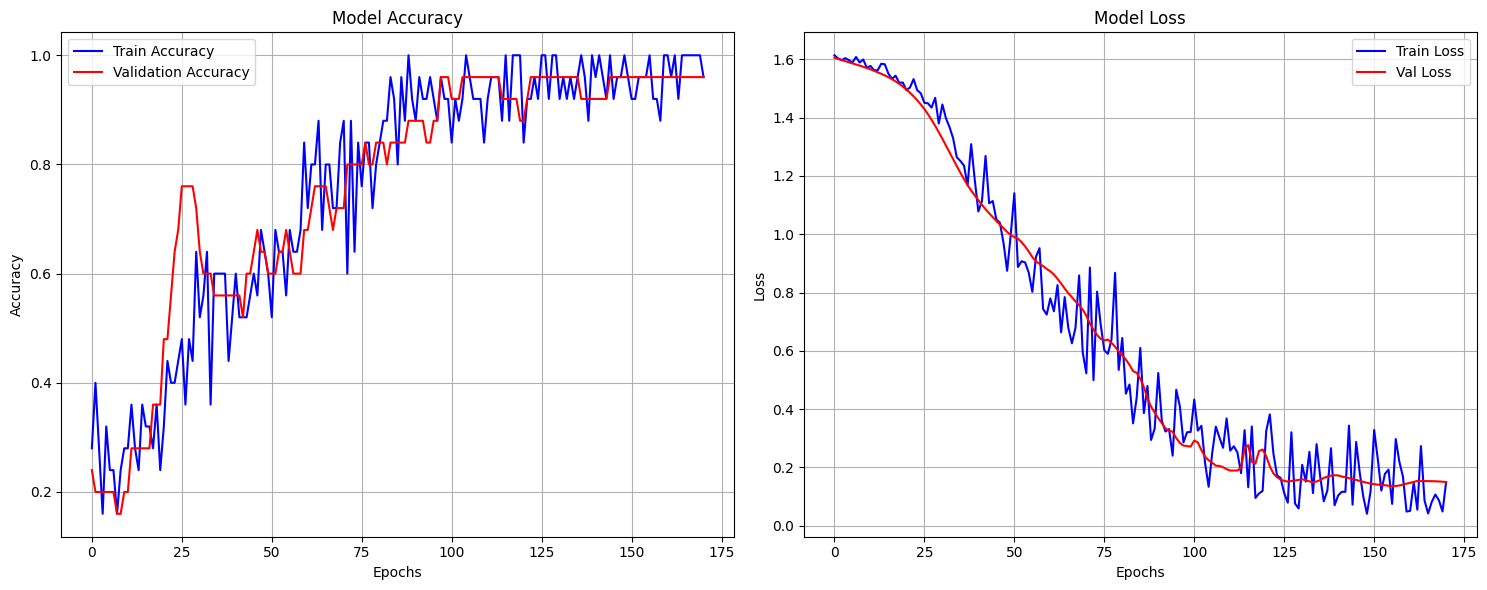


🎉 모든 과정이 완료되었습니다! Google Drive의 'final_model' 폴더에서 best_model.pth와 label_map.json 파일을 다운로드하여 사용하세요.


In [ ]:
# ==================================================================
# 6. 결과 저장 및 시각화
# ==================================================================
print("\n✅ 6. 최종 결과물 저장 및 시각화 시작")
label_map_path = os.path.join(MODEL_SAVE_DIR, 'label_map_5_words_high_quality.json')
with open(label_map_path, 'w', encoding='utf-8') as f:
    json.dump(global_label_map, f, ensure_ascii=False, indent=4)
print(f"라벨 맵 저장 완료: {label_map_path}")
def plot_history(history):
    plt.figure(figsize=(15, 6)); plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], 'b-', label='Train Accuracy'); plt.plot(history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Model Accuracy'); plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.grid(True); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], 'b-', label='Train Loss'); plt.plot(history['val_loss'], 'r-', label='Val Loss')
    plt.title('Model Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()
plot_history(history)
print("\n🎉 모든 과정이 완료되었습니다! Google Drive의 'final_model_5_words_high_quality' 폴더에서 결과물을 다운로드하여 사용하세요.")

In [ ]:
!pip install onnx onnxruntime onnx-simplifier

In [ ]:
# ONNX 변환 로직

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import onnxruntime
import os

# ==================================================================
# 1. 모델 클래스 정의 (훈련 시 사용한 것과 100% 동일해야 함)
# ==================================================================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_outputs):
        scores = self.attention(lstm_outputs).squeeze(2)
        weights = F.softmax(scores, dim=1)
        return torch.bmm(weights.unsqueeze(1), lstm_outputs).squeeze(1)

class KeypointLSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size=256, num_layers=2, dropout=0.5):
        super(KeypointLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        self.attention = Attention(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context_vector = self.attention(lstm_out)
        return self.fc(self.dropout(context_vector))

# ==================================================================
# 2. 변환 설정
# ==================================================================
# --- 자신의 환경에 맞게 경로와 파일 이름을 수정하세요 ---
# Google Drive에 저장된 모델 경로 (Colab에서 실행 시)
MODEL_SAVE_DIR = '/content/drive/MyDrive/handshacke/final_model'
PTH_FILE_PATH = os.path.join(MODEL_SAVE_DIR, '/content/drive/MyDrive/handshacke/final_model_5_words_corrected/best_model_5_words_high_quality.pth')

# 최종 ONNX 파일 이름
ONNX_FILE_PATH = 'sign_language_model_5_words.onnx'

# --- 훈련 시 사용했던 모델 파라미터 (매우 중요) ---
NUM_CLASSES = 5  # 5개 단어로 훈련했으므로 5로 설정
KEYPOINT_DIM = 137 * 3
SEQUENCE_LENGTH = 150
DEVICE = torch.device('cpu') # ONNX 변환은 CPU에서 하는 것이 안전합니다.

# ==================================================================
# 3. 모델 로드 및 ONNX 변환
# ==================================================================
print(f"'{PTH_FILE_PATH}' 파일에서 가중치를 로드합니다...")

# 1. 모델 인스턴스 생성 (훈련 때와 동일한 파라미터 사용)
model = KeypointLSTM(
    num_classes=NUM_CLASSES,
    input_size=KEYPOINT_DIM
).to(DEVICE)

# 2. 저장된 가중치 불러오기
# map_location=DEVICE를 통해 CPU로 가중치를 불러옵니다.
model.load_state_dict(torch.load(PTH_FILE_PATH, map_location=DEVICE))
model.eval() # 추론 모드로 설정
print("✅ 모델 로드 완료.")

# 3. 더미 입력(Dummy Input) 생성
# ONNX 모델에 입력 데이터의 형태를 알려주기 위함입니다.
batch_size = 1
dummy_input = torch.randn(batch_size, SEQUENCE_LENGTH, KEYPOINT_DIM).to(DEVICE)

# 4. ONNX로 내보내기 (Export)
print(f"\n모델을 '{ONNX_FILE_PATH}' 파일로 변환합니다...")
try:
    torch.onnx.export(
        model,
        dummy_input,
        ONNX_FILE_PATH,
        input_names=['input'],      # ONNX 모델의 입력 레이어 이름
        output_names=['output'],    # ONNX 모델의 출력 레이어 이름
        opset_version=12,           # ONNX 버전
        dynamic_axes={              # 배치 크기를 가변적으로 설정
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        }
    )
    print(f"✅ ONNX 변환 성공! -> {ONNX_FILE_PATH}")

    # ==================================================================
    # 4. 변환 검증 (선택 사항이지만 강력히 권장)
    # ==================================================================
    print("\n--- ONNX 모델 검증 시작 ---")
    # PyTorch 모델 추론
    with torch.no_grad():
        pytorch_output = model(dummy_input)

    # ONNX 런타임 세션 생성 및 추론
    ort_session = onnxruntime.InferenceSession(ONNX_FILE_PATH)
    ort_inputs = {ort_session.get_inputs()[0].name: dummy_input.cpu().numpy()}
    onnx_output = ort_session.run(None, ort_inputs)

    # 결과 비교 (두 결과가 거의 일치하는지 확인)
    np.testing.assert_allclose(pytorch_output.cpu().numpy(), onnx_output[0], rtol=1e-03, atol=1e-05)
    print("✅ 검증 성공: PyTorch 모델과 ONNX 모델의 출력이 일치합니다.")

except Exception as e:
    print(f"❌ 변환 또는 검증 실패: {e}")